# Building an Image Recognition System for Quality Control

### Import Libraries

In [4]:
!python -m pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- -------------------------

In [1]:
!python -m pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.3.0-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.83.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached m

### Import Libraries

In [53]:
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

data_path = Path(
    r"C:\Users\nidhi\Downloads\casting_512x512\casting_512x512"
)

output_path = Path(
    r"C:\Users\nidhi\Downloads\casting_split"
)

for folder in ["train", "validation", "test"]:
    for class_name in ["ok_front", "def_front"]:
        (output_path / folder / class_name).mkdir(
            parents=True,
            exist_ok=True
        )

for class_name in ["ok_front", "def_front"]:

    class_path = data_path / class_name

    # Only actual image files
    images = [
        image for image in class_path.iterdir()
        if image.is_file()
    ]

    print(class_name, "total:", len(images))

    train_images, temp_images = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    validation_images, test_images = train_test_split(
        temp_images,
        test_size=0.50,
        random_state=42
    )

    for image in train_images:
        shutil.copy2(
            image,
            output_path / "train" / class_name / image.name
        )

    for image in validation_images:
        shutil.copy2(
            image,
            output_path / "validation" / class_name / image.name
        )

    for image in test_images:
        shutil.copy2(
            image,
            output_path / "test" / class_name / image.name
        )

print("Dataset split completed!")

ok_front total: 519
def_front total: 781
Dataset split completed!


In [54]:
import tensorflow as tf

image_size = (224, 224)
batch_size = 32

class_names = ["ok_front", "def_front"]

train_dataset = tf.keras.utils.image_dataset_from_directory(
    output_path / "train",
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    output_path / "validation",
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    output_path / "test",
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

print("All datasets loaded!")

Found 909 files belonging to 2 classes.
Found 195 files belonging to 2 classes.
Found 196 files belonging to 2 classes.
All datasets loaded!


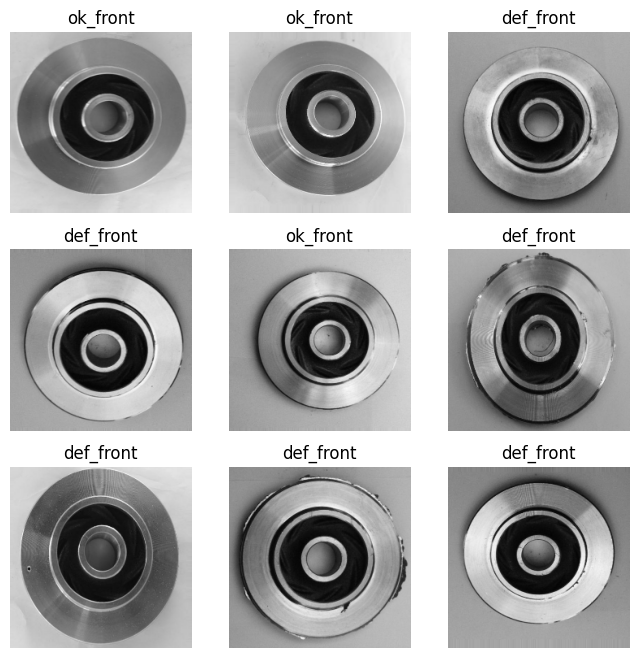

In [55]:
plt.figure(figsize=(8, 8))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[int(labels[i])])

        plt.axis("off")

plt.show()

In [56]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10)
])

print("Data augmentation ready!")

Data augmentation ready!


In [57]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Rescaling(1.0 / 255),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully!")

Model compiled successfully!


In [59]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.000001
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_casting_defect_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks ready!")

Callbacks ready!


In [60]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 560ms/step - accuracy: 0.5974 - loss: 0.6733 - precision: 0.6051 - recall: 0.9487 - val_accuracy: 0.6000 - val_loss: 0.7183 - val_precision: 0.6000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 565ms/step - accuracy: 0.6007 - loss: 0.6797 - precision: 0.6009 - recall: 0.9982 - val_accuracy: 0.6000 - val_loss: 0.6591 - val_precision: 0.6000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 555ms/step - accuracy: 0.6007 - loss: 0.6567 - precision: 0.6007 - recall: 1.0000 - val_accuracy: 0.6000 - val_loss: 0.6664 - val_precision: 0.6000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 560ms/step - accuracy: 0.6007 - loss: 0.6393 - precision: 0.6011 - recall: 0.9963 - val_accuracy: 0.6000 - val_loss: 0.6330 - val_precision: 0.6000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 558ms/step - accur

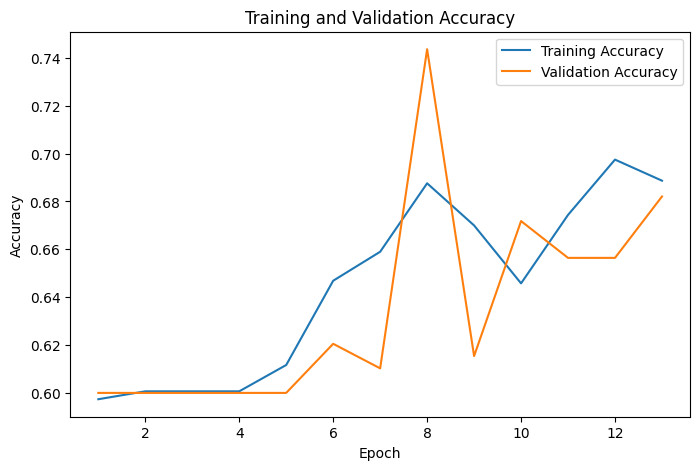

In [61]:
training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]

epochs = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    validation_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

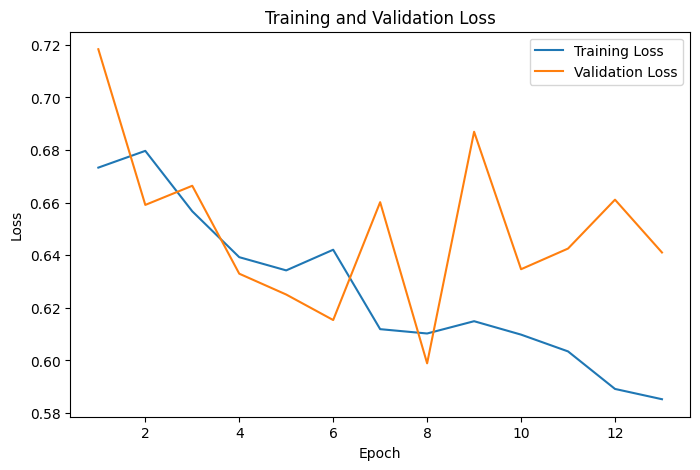

In [62]:
training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_loss,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

In [63]:
test_results = model.evaluate(test_dataset)

print("Test Results:")
print(test_results)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.7398 - loss: 0.5706 - precision: 0.7376 - recall: 0.8814    
Test Results:
[0.5706226825714111, 0.7397959232330322, 0.73758864402771, 0.8813559412956238]


In [64]:
prediction_probabilities = model.predict(test_dataset)

predicted_labels = (
    prediction_probabilities.flatten() >= 0.5
).astype(int)

actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

print("Predictions completed!")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step
Predictions completed!


In [65]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=[
            "Non-defective",
            "Defective"
        ]
    )
)

               precision    recall  f1-score   support

Non-defective       0.75      0.53      0.62        78
    Defective       0.74      0.88      0.80       118

     accuracy                           0.74       196
    macro avg       0.74      0.70      0.71       196
 weighted avg       0.74      0.74      0.73       196



Confusion Matrix:
[[ 41  37]
 [ 14 104]]


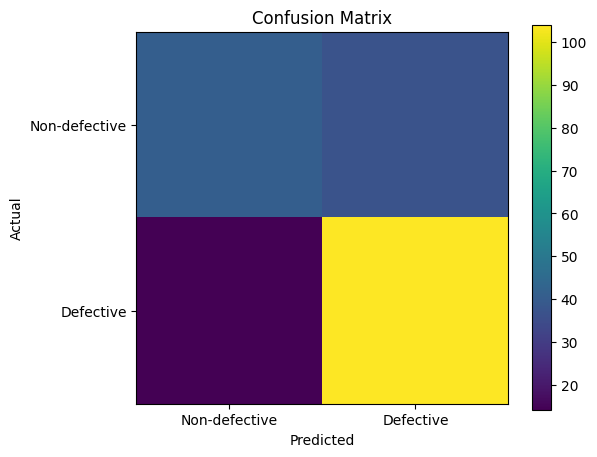

In [66]:
matrix = confusion_matrix(
    actual_labels,
    predicted_labels
)

print("Confusion Matrix:")
print(matrix)

plt.figure(figsize=(6, 5))

plt.imshow(matrix)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Non-defective", "Defective"]
)

plt.yticks(
    [0, 1],
    ["Non-defective", "Defective"]
)

plt.colorbar()

plt.show()

In [67]:
tn, fp, fn, tp = matrix.ravel()

print("False Positive:", fp)
print("False Negative:", fn)

False Positive: 37
False Negative: 14


In [68]:
print("Test Accuracy:", test_results[1])
print("False Positive:", fp)
print("False Negative:", fn)

Test Accuracy: 0.7397959232330322
False Positive: 37
False Negative: 14


In [69]:
def predict_product(image_path):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)

    image_array = tf.expand_dims(
        image_array,
        axis=0
    )

    probability = float(
        model.predict(
            image_array,
            verbose=0
        )[0][0]
    )

    if probability >= 0.50:

        prediction = "Defective"
        action = "Send for manual inspection"

    else:

        prediction = "Non-defective"
        action = "Product may proceed"

    print("Prediction:", prediction)
    print("Defect probability:", f"{probability:.2%}")
    print("Recommended action:", action)

In [71]:
from pathlib import Path

folder = Path(
    r"C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front"
)

images = list(folder.glob("*"))

print("Images found:", len(images))

for image in images[:10]:
    print(image)

Images found: 519
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1018.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1021.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1028.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1074.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1082.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1083.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1091.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1092.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1102.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1144.jpeg


In [72]:
image_path = str(images[0])

print("Testing image:")
print(image_path)

predict_product(image_path)

Testing image:
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1018.jpeg
Prediction: Non-defective
Defect probability: 39.46%
Recommended action: Product may proceed


In [73]:
def_folder = Path(
    r"C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\def_front"
)

def_images = list(def_folder.glob("*"))

print("Defective images found:", len(def_images))

image_path = str(def_images[0])

print("Testing image:")
print(image_path)

predict_product(image_path)

Defective images found: 781
Testing image:
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\def_front\cast_def_0_0.jpeg
Prediction: Defective
Defect probability: 93.46%
Recommended action: Send for manual inspection
